# Histograms

Given a grayscale image, its **histograms** consists of its gray levels; that is, it is a graph indicating the number of times each gray level occurs in the image.

### Library Imports

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display

### Constants

In [2]:
IMG_PATH = "data/clay-banks-fZHP8uq6WhQ-unsplash_fl_stein.png"
DARK_IMG_PATH = "data/ivanelia-ivanova-2z5Yhgd2ZUs-unsplash.jpg"
WHITE_IMG_PATH = "data/jocelyn-morales-Xzgo7v0oKVk-unsplash.jpg" 

## Histograms of Dark Image

### Helper Functions

In [3]:
# Open and retrieve image pixels
def retrieve_pixels(img_path: str) -> np.ndarray:
    """
    Retrieve and return the grayscale pixel array from an image file.
    """
    
    img = Image.open(img_path).convert('L')
    return np.array(img).astype(np.uint8)


def display_imgs(img_list: list, labels):
    """
    Display a list of images along with their labels in the same plot.
    """
    
    fig, axs = plt.subplots(1, len(img_list), figsize=(20, 6))
    for ax, img, title in zip(axs, img_list, labels):
        ax.imshow(img, cmap='gray', vmin=0, vmax=255)
        ax.set_title(title)
        ax.axis("off")
    
    plt.tight_layout()
    plt.show()

def display_histograms(img_list, labels):
    """
    Display grayscale histograms for a list of image pixel arrays.
    """

    fig, axs = plt.subplots(1, len(img_list), figsize=(20, 6))

    for ax, img_pixels, title in zip(axs, img_list, labels):
        flat = img_pixels.flatten()
        ax.hist(flat, bins=256, range=(0, 256), color='gray', density=False)
        ax.set_title(title)
        ax.set_xlabel("Pixel value")
        ax.set_ylabel("Frequency")

    plt.tight_layout()
    plt.show()

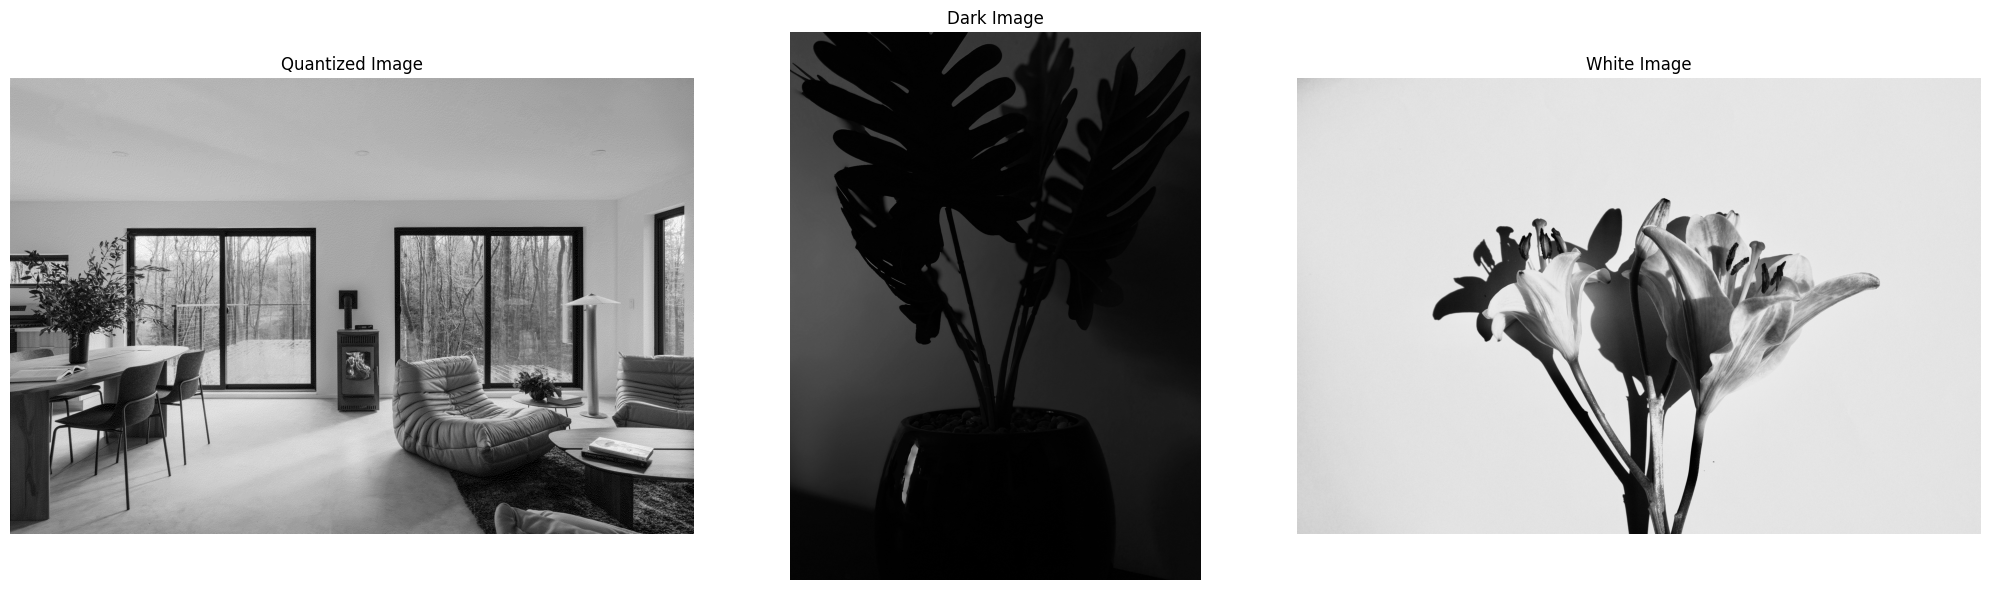

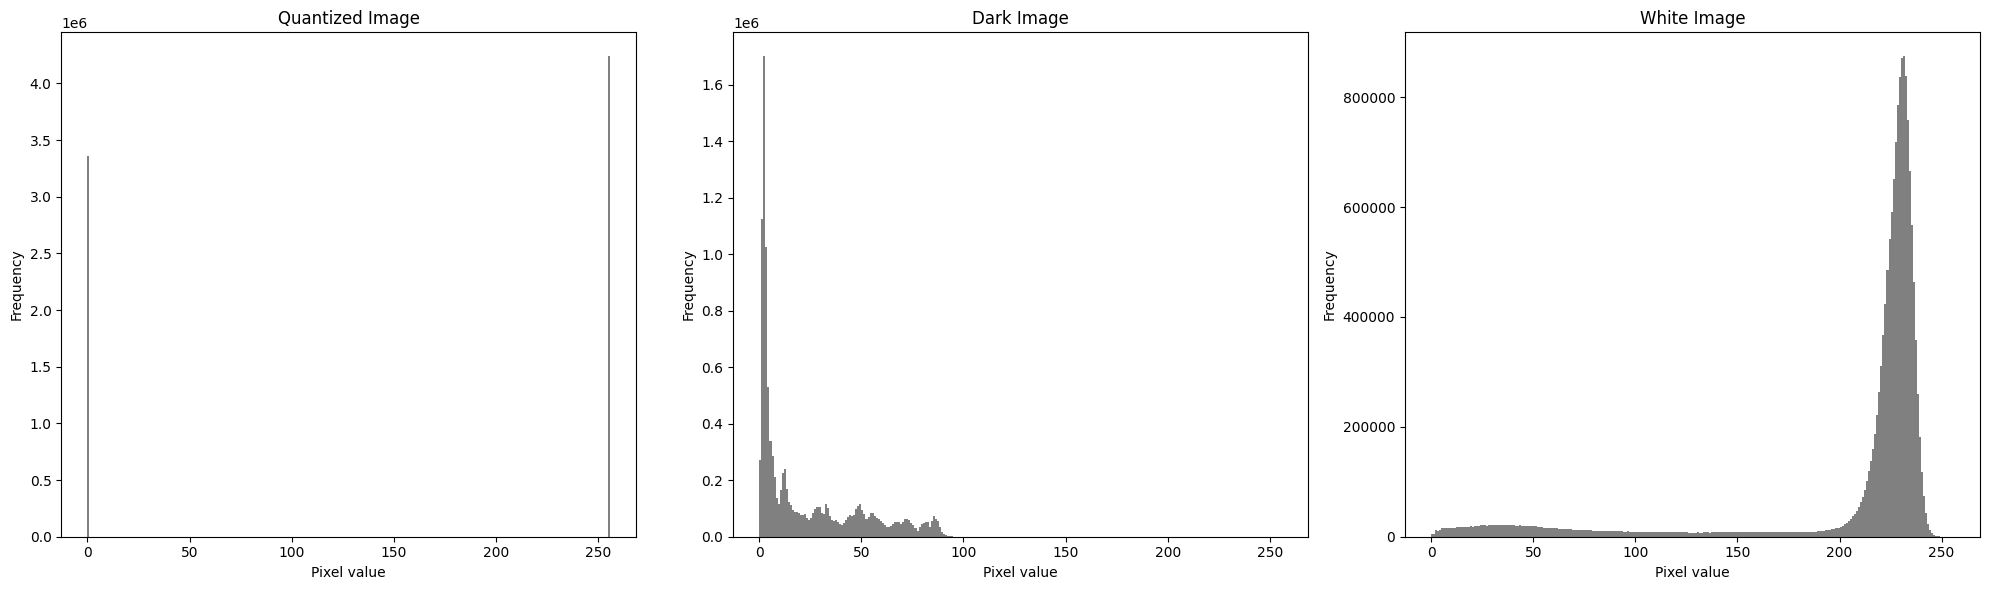

In [4]:
imgs = [retrieve_pixels(p) for p in [IMG_PATH, DARK_IMG_PATH, WHITE_IMG_PATH]]
labels = ["Quantized Image", "Dark Image",  "White Image"]

display_imgs(imgs, labels)
display_histograms(imgs, labels)

As we can see here, in the dark image the gray levels are clustered at the lower end. But in the case of a brighter image, the gray level are clustered ath the upper end.

## Histogram Stretching

Histogram stretching allow us to stretch out the gray levels to enhance the image contrast to obtain a more uniform display.

In [5]:
def plot_histogram(counts: np.ndarray, title: str = "Image Histogram"):
    """
    Plots the histogram counts.
    
    Args:
        counts (np.ndarray): The histogram counts (256 elements).
        title (str): The title for the plot.
    """
    # Create the X-axis values (gray levels 0 to 255)
    gray_levels = np.arange(len(counts)) 

    plt.figure(figsize=(10, 5))
    
    # Use 'plt.bar' to draw the histogram bars
    plt.bar(gray_levels, counts, width=1.0, color='gray') 
    
    plt.title(title)
    plt.xlabel('Intensity Value (Gray Level, $r_k$)')
    plt.ylabel('Number of Pixels ($h(r_k)$)')
    plt.xlim(0, 255) # Set limits to span the full 8-bit range
    plt.grid(axis='y', alpha=0.5)
    plt.show()


def hist_equalization(img: np.ndarray) -> np.ndarray:
    """
    Apply histogram equalization procedure to the gray level values of a grayscale image.
    """

    # 1. Calculate Histogram
    # We use bins=256 for gray levels 0-255. `counts` is the histogram h(i).
    counts, bins = np.histogram(img, bins=256, range=(0, 255), density=False)
    
    # 2. Calculate the Cumulative Distribution Function (CDF) and scale it
    # Total number of pixels is N = np.sum(counts).
    # L = 256 is the number of gray levels. 
    # The scaling factor is (L-1)/N
    
    # Adjust the coefficient to the standard (L-1)/N = 255/N for 8-bit image
    N = np.sum(counts)
    L_minus_1 = 255 
    coef = L_minus_1 / N
    
    # Calculate the scaled and rounded CDF: s_k = round((L-1)/N * C(k))
    # where C(k) is the cumulative sum C(k) = sum(h(i) for i <= k)
    cumulative_sum = np.cumsum(counts)
    weighted_rounded_cumsum = np.round(coef * cumulative_sum).astype('uint8')

    # The index of weighted_rounded_cumsum corresponds to the original gray level (0-255).
    # Use the original image as the indices to lookup the new values
    equalized_img = weighted_rounded_cumsum[img]

    return equalized_img

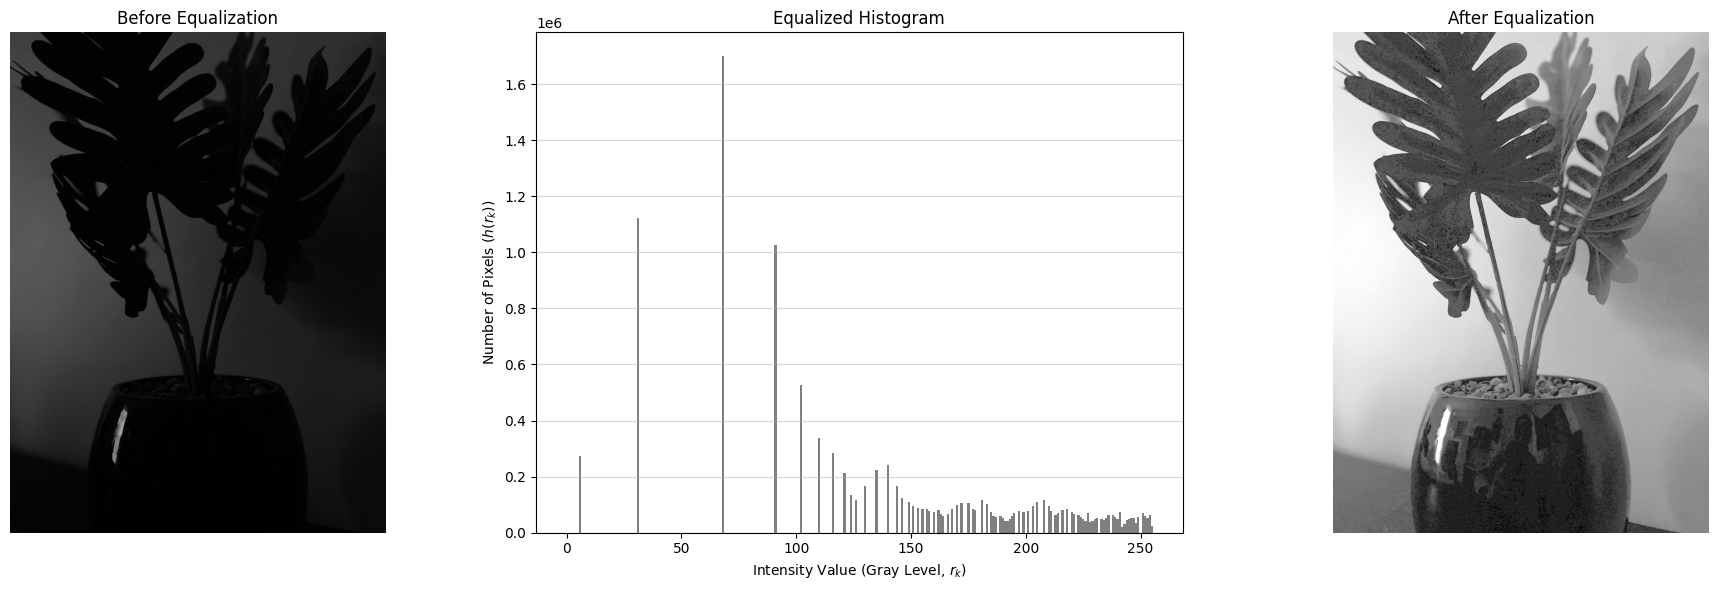

In [6]:
equalized_arr = hist_equalization(imgs[1])
equalized_img = Image.fromarray(equalized_arr)
counts_equalized, _ = np.histogram(equalized_img, bins=256, range=(0, 255), density=False)

# Display images and histogram
fig, axs = plt.subplots(1, 3, figsize=(20, 6))
axs[0].imshow(imgs[1], cmap='gray', vmin=0, vmax=255)
axs[0].set_title("Before Equalization")
axs[0].axis("off")

gray_levels = np.arange(len(counts_equalized)) 
axs[1].bar(gray_levels, counts_equalized, width=1.0, color='gray') 
axs[1].grid(axis='y', alpha=0.5)
axs[1].set_title("Equalized Histogram")
axs[1].set_xlabel("Intensity Value (Gray Level, $r_k$)")
axs[1].set_ylabel("Number of Pixels ($h(r_k)$)")

axs[2].imshow(equalized_img, cmap='gray', vmin=0, vmax=255)
axs[2].set_title("After Equalization")
axs[2].axis("off")

plt.tight_layout()
plt.show()

The histogram equalization procedure provide a cleaner, brighter and sharper image where the details are more visible, especially with the reflections that were totally invisible before. 

## References
- Introduction to Digital Image Processing with MATLAB, Alasdair McAndrew, 2004
- Photo by <a href="https://unsplash.com/@ivanelia?utm_source=unsplash&utm_medium=referral&utm_content=creditCopyText">Ivanelia Ivanova</a> on <a href="https://unsplash.com/photos/a-black-vase-with-a-plant-in-it-2z5Yhgd2ZUs?utm_source=unsplash&utm_medium=referral&utm_content=creditCopyText">Unsplash</a>
- Photo by <a href="https://unsplash.com/@molnj?utm_source=unsplash&utm_medium=referral&utm_content=creditCopyText">Jocelyn Morales</a> on <a href="https://unsplash.com/photos/white-flowers-in-grayscale-photography-Xzgo7v0oKVk?utm_source=unsplash&utm_medium=referral&utm_content=creditCopyText">Unsplash</a>
      